In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample


In [16]:

# Import MDSS (Assuming library is installed/available)
from mdss.MDSS import MDSS
from mdss.ScoringFunctions.Bernoulli import Bernoulli

# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
print("--- 1. Loading & Preprocessing ---")

# Load Data
tax_df = pd.read_excel('/Users/kayadetunji/Documents/DM_work/raw data_taxonomy_CFC.xlsx', sheet_name='taxonomy')
chem_df = pd.read_excel('/Users/kayadetunji/Documents/DM_work/raw data_taxonomy_CFC.xlsx', sheet_name='properties')

# Define Groups
gz_cols = ['GZ1', 'GZ2', 'GZ3', 'GZ4']
ag_cols = ['AG1', 'AG2', 'AG3', 'AG4']
all_samples = gz_cols + ag_cols

# Filter Rare Taxa (Prevalence > 3 samples) - Crucial for Network Stability
counts = tax_df[all_samples]
mask = (counts > 0).sum(axis=1) >= 3
df_clean = tax_df[mask].reset_index(drop=True)
print(f"Taxa retained for Network Analysis: {len(df_clean)}")

# CLR Transformation (Centered Log-Ratio) - The STORMS Standard
# Log-transform counts relative to the geometric mean per sample
def clr_transform(count_df):
    # Add pseudo-count to handle zeros
    df_log = np.log(count_df + 1)
    # Subtract geometric mean (mean of logs)
    geometric_mean = df_log.mean(axis=0) # centered on sample
    return df_log.sub(geometric_mean, axis=1)

df_clr = clr_transform(df_clean[all_samples])
# Transpose for Correlation (Rows=Samples, Cols=Taxa)
X = df_clr.T 

# ==========================================
# 2. ROBUST NETWORK CONSTRUCTION (Bootstrapping)
# ==========================================
print("\n--- 2. Constructing Robust Network (Bootstrapped) ---")
# Problem: N=12 is small. 
# Solution: Run 100 bootstraps. Only keep edges that appear in >70% of runs.

n_boot = 50  # Use 50-100 for speed (increase for final paper)
threshold_rho = 0.7 # Strong correlation only
consensus_matrix = np.zeros((X.shape[1], X.shape[1]))

print(f"Running {n_boot} bootstrap iterations...")
for i in range(n_boot):
    # Resample samples with replacement
    X_resampled = resample(X)
    
    # Calculate Spearman Correlation
    corr, _ = spearmanr(X_resampled)
    # Handle NaNs if any variance is 0
    corr = np.nan_to_num(corr)
    
    # Binarize: 1 if correlation is strong, 0 otherwise
    # adj = (np.abs(corr) >= threshold_rho).astype(int)
    adj = (corr >= threshold_rho).astype(int)   # positive only
    consensus_matrix += adj

# Normalize consensus (0.0 to 1.0 probability of edge)
consensus_matrix = consensus_matrix / n_boot

# Final Adjacency: Keep edges present in >70% of bootstraps
final_adjacency = (consensus_matrix >= 0.7).astype(int)
np.fill_diagonal(final_adjacency, 0) # Self-correlation is 1

print(f"Network Constructed. Density: {np.mean(final_adjacency):.3f}")


--- 1. Loading & Preprocessing ---
Taxa retained for Network Analysis: 298

--- 2. Constructing Robust Network (Bootstrapped) ---
Running 50 bootstrap iterations...
Network Constructed. Density: 0.019



--- 3. Detecting Ecological Modules ---


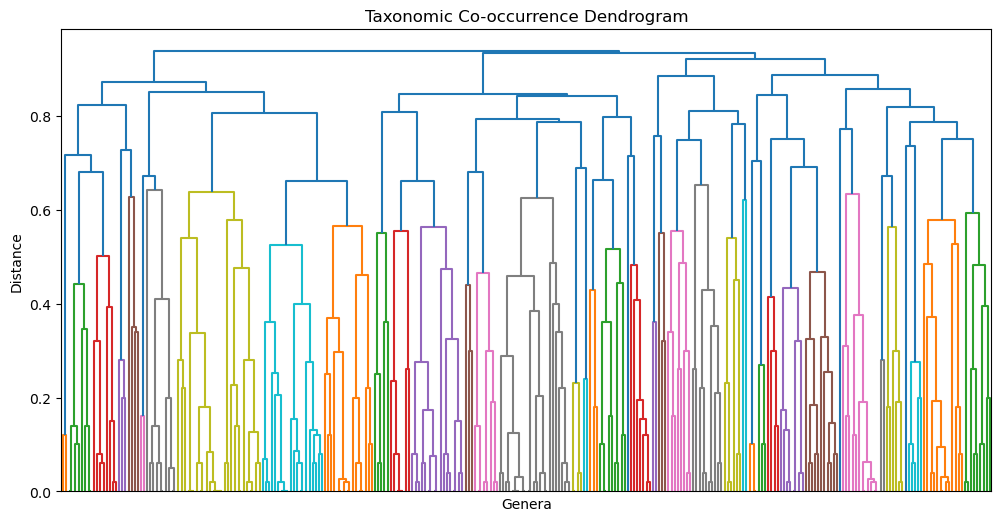

Identified 4 distinct Co-abundance Modules.

--- 4. Module Annotation ---
  Module  Size Dominant_Phylum  \
0     M1   100  Proteobacteria   
1     M2    89  Actinobacteria   
2     M3    31  Actinobacteria   
3     M4    78  Actinobacteria   

                               Representative_Genera  
0  [Acidithiomicrobium, Actinoplanes, Aeromicrobium]  
1         [Acholeplasma, Acidovorax, Actinocorallia]  
2        [Acidothermus, Actinobaculum, Actinomadura]  
3        [Acetobacter, Acidimicrobium, Acidiphilium]  

--- 5. Calculating Module Eigengenes ---
     Module_1  Module_2  Module_3  Module_4    pH  Nitrate  Zone
GZ1  0.684405 -0.142323 -0.066503 -2.921030  6.79    16.56     0
GZ2 -1.468980  3.419833  3.460922  0.046932  7.04    16.42     0
GZ3 -2.138326 -0.104151 -1.614287 -7.818713  6.64    18.02     0
GZ4 -7.204013 -4.664111  6.390893 -5.493058  6.45    14.16     0
AG1 -7.475934  7.606308  0.539634  2.324232  5.49     0.97     1

--- 6. MDSS Interaction Scan ---

MDSS Score: 1

In [19]:


# ==========================================
# 3. MODULE DETECTION (Hierarchical Clustering)
# ==========================================
print("\n--- 3. Detecting Ecological Modules ---")
# Convert Consensus Matrix to Distance (1 - Consensus)
# Taxa that are often correlated have distance close to 0
dist_matrix = 1 - consensus_matrix
dist_array = squareform(dist_matrix, checks=False)

# Hierarchical Clustering (Ward's Method)
# Z = linkage(dist_array, method='ward')
Z = linkage(squareform(dist_matrix, checks=False), method='average')

# Plot Dendrogram (Visual Check)
plt.figure(figsize=(12, 6))
dendrogram(Z, no_labels=True, color_threshold=0.7*max(Z[:,2]))
plt.title("Taxonomic Co-occurrence Dendrogram")
plt.xlabel("Genera")
plt.ylabel("Distance")
plt.show()

# Cut Tree to define Modules
# Adjust 't' (distance threshold) to get 5-10 modules
# cluster_labels = fcluster(Z, t=4, criterion='maxclust') 
# df_clean['Module_ID'] = cluster_labels

# Cut into 4 modules
cluster_labels = fcluster(Z, 4, criterion='maxclust')
df_clean['Module_ID'] = cluster_labels
n_modules = len(np.unique(cluster_labels))
print(f"Identified {n_modules} distinct Co-abundance Modules.")

# ==========================================
# 4. ANNOTATE MODULES (Who is in them?)
# ==========================================
print("\n--- 4. Module Annotation ---")

module_stats = []
for mod_id in np.sort(np.unique(cluster_labels)):
    members = df_clean[df_clean['Module_ID'] == mod_id]
    size = len(members)
    
    # Dominant Phylum
    top_phylum = members['phylum'].mode()[0] if not members['phylum'].mode().empty else "Mix"
    
    # Top 3 Genera names
    top_genera = members['genus'].head(3).tolist()
    
    module_stats.append({
        'Module': f"M{mod_id}",
        'Size': size,
        'Dominant_Phylum': top_phylum,
        'Representative_Genera': top_genera
    })

df_modules = pd.DataFrame(module_stats)
print(df_modules)

# ==========================================
# 5. CALCULATE EIGENGENES (Module Scores)
# ==========================================
print("\n--- 5. Calculating Module Eigengenes ---")

# Eigengene = PC1 of the CLR data for that module
eigengenes = pd.DataFrame(index=all_samples)

pca = PCA(n_components=1)
for mod_id in np.unique(cluster_labels):
    # Get CLR data for just this module
    mod_indices = df_clean.index[df_clean['Module_ID'] == mod_id]
    mod_data = df_clr.iloc[mod_indices].T # Samples x Taxa
    
    # Run PCA
    pc1 = pca.fit_transform(StandardScaler().fit_transform(mod_data))
    
    # Store Score (PC1)
    eigengenes[f"Module_{mod_id}"] = pc1.flatten()

# Add Metadata (Zone, pH, Nitrate)
# We need to extract pH/Nitrate from chem_df and align
chem_t = chem_df.set_index('Variable').T
eigengenes['pH'] = chem_t.loc[all_samples, 'pH'].astype(float)
eigengenes['Nitrate'] = chem_t.loc[all_samples, 'N–NO3(mg/kg)'].astype(float)
eigengenes['Zone'] = [1 if 'AG' in x else 0 for x in all_samples] # 1=Degraded, 0=Healthy

print(eigengenes.head())

# ==========================================
# 6. MDSS RULE MINING (The Interaction Check)
# ==========================================
print("\n--- 6. MDSS Interaction Scan ---")
# We scan Eigengenes + Chemistry to predict Zone (Degraded)

# Features: Module Scores + pH/Nitrate
features = eigengenes.drop(columns=['Zone'])

# Binarize Features for MDSS (High vs Low)
# This creates columns like "Module_1_High", "pH_Low"
features_bin = pd.DataFrame()
for col in features.columns:
    median_val = features[col].median()
    features_bin[f"{col}_High"] = (features[col] > median_val).astype(int)
    features_bin[f"{col}_Low"] = (features[col] <= median_val).astype(int)

# Outcome: Is it Agricultural Soil?
outcome = eigengenes['Zone']
# Expectation: Baseline probability (0.5 for balanced dataset)
expectation = pd.Series([0.5]*len(outcome), index=outcome.index)

# Setup MDSS Scanner (Bernoulli because Outcome is Binary Class)
scoring_function = Bernoulli(direction='positive') # Look for rule that predicts Class=1 (AG)
scanner = MDSS(scoring_function)

# Run Scan
subset, score = scanner.scan(
    coordinates=features_bin,
    outcomes=outcome,
    expectations=expectation,
    penalty=1.0,
    num_iters=10,
    mode='binary',
    verbose=False
)

print(f"\nMDSS Score: {score:.4f}")
print("Top Interaction Rule predicting Soil Degradation:")
print(subset)

# Interpretation Logic
print("\n--- INTERPRETATION HELP ---")
print("1. Look at 'Module Annotation': Which module contains the N-fixers (Azospirillum)?")
print("2. Look at 'MDSS Rule': Did the scanner pick that specific module?")
print("   Example: If Rule is {'Module_2_Low': [1], 'pH_Low': [1]}, it means")
print("   'When Module 2 collapses AND pH is low, the soil is Degraded.'")

Generating Figure 1: Network Topology...


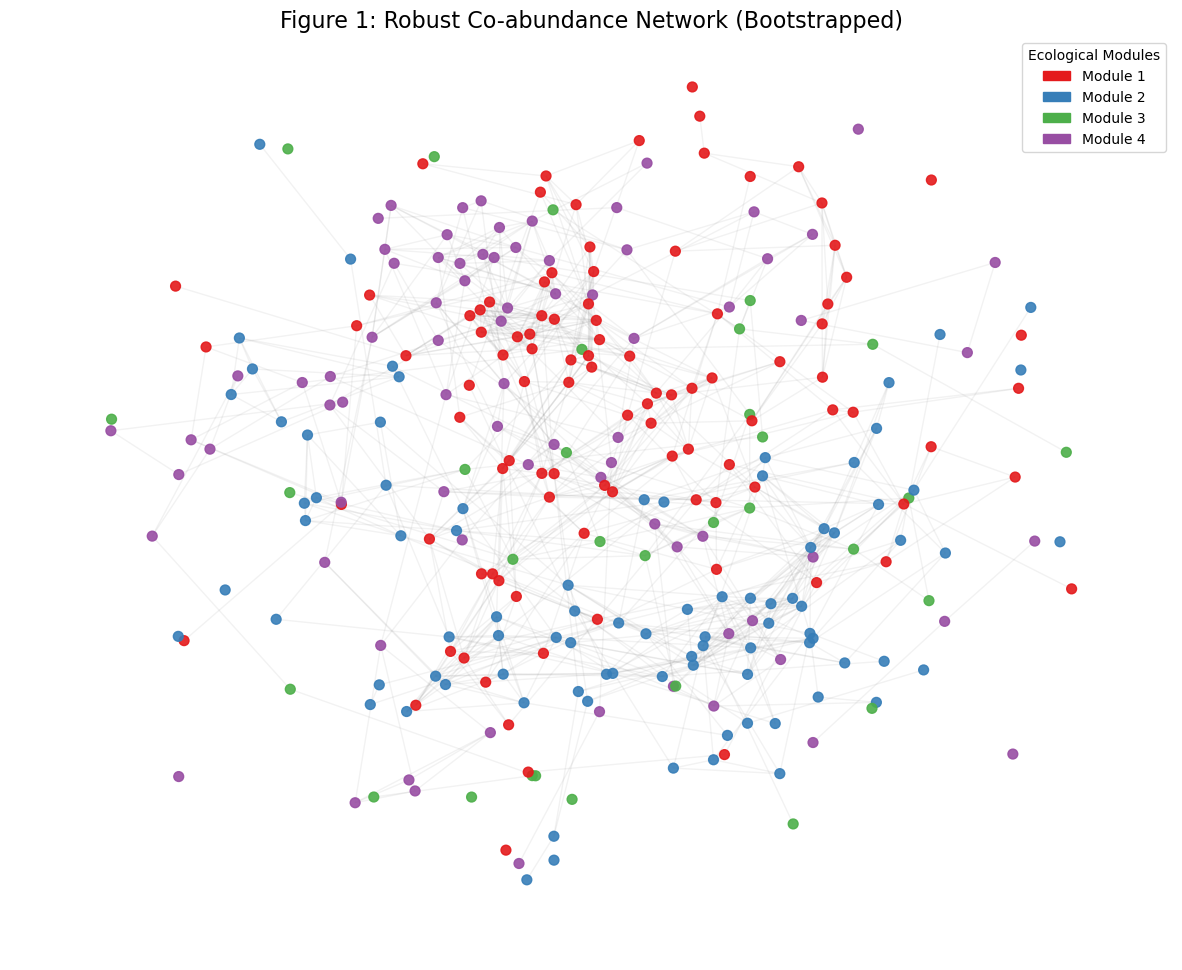

Generating Figure 2: Module Composition...


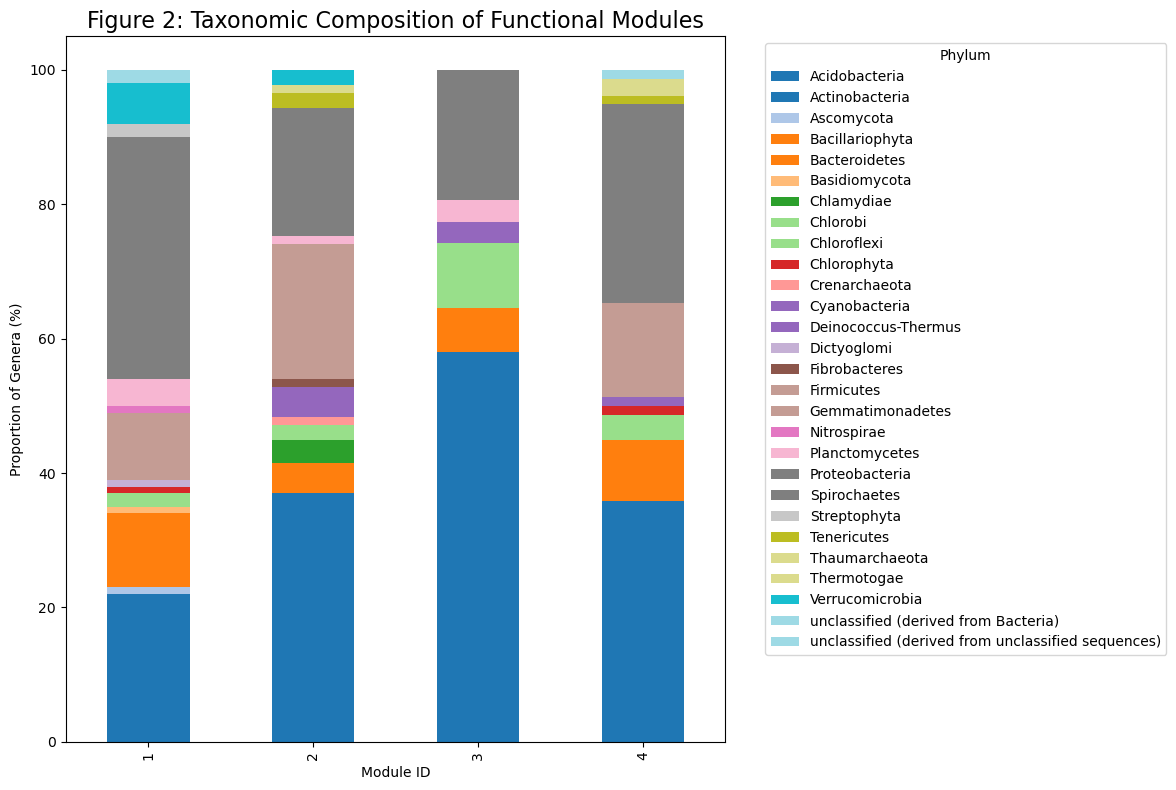

Generating Figure 3: Eigengene Response...


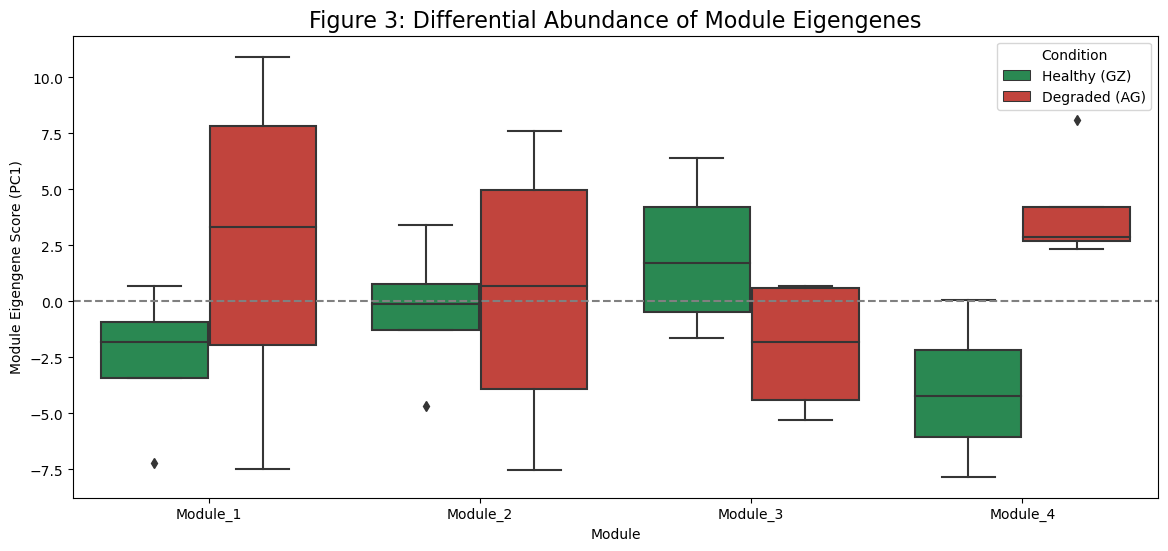

In [20]:
import networkx as nx
import matplotlib.patches as mpatches

# ==========================================
# FIGURE 1: THE NETWORK TOPOLOGY PLOT
# ==========================================
# We use the 'final_adjacency' matrix (edges > 70% bootstrap support)

print("Generating Figure 1: Network Topology...")
plt.figure(figsize=(15, 12))

# 1. Create Graph Object
G = nx.from_numpy_array(final_adjacency)

# 2. Map Node Attributes (Module Color)
# We need a color map for M1, M2, M3, M4
module_map = df_clean['Module_ID'].to_dict()
# Colors: M1=Red, M2=Blue, M3=Green, M4=Purple
color_palette = {1: '#e41a1c', 2: '#377eb8', 3: '#4daf4a', 4: '#984ea3'}
node_colors = [color_palette.get(module_map.get(i), 'grey') for i in G.nodes()]

# 3. Layout (Fruchterman-Reingold is standard for force-directed)
pos = nx.spring_layout(G, k=0.15, iterations=20, seed=42)

# 4. Draw
# Draw edges (light grey)
nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='grey')
# Draw nodes (colored by module)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=50, alpha=0.9)

# 5. Legend
legend_handles = [mpatches.Patch(color=color, label=f"Module {m}") for m, color in color_palette.items()]
plt.legend(handles=legend_handles, title="Ecological Modules", loc='upper right')
plt.title("Figure 1: Robust Co-abundance Network (Bootstrapped)", fontsize=16)
plt.axis('off')
plt.show()

# ==========================================
# FIGURE 2: MODULE COMPOSITION (Stacked Bar)
# ==========================================
# "Who is in these modules?"

print("Generating Figure 2: Module Composition...")
# Crosstab Module vs Phylum
mod_comp = pd.crosstab(df_clean['Module_ID'], df_clean['phylum'])
# Normalize to percentages
mod_comp_pct = mod_comp.div(mod_comp.sum(axis=1), axis=0) * 100

# Plot
ax = mod_comp_pct.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='tab20')
plt.title("Figure 2: Taxonomic Composition of Functional Modules", fontsize=16)
plt.xlabel("Module ID")
plt.ylabel("Proportion of Genera (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Phylum')
plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 3: MODULE RESPONSE (Box Plots)
# ==========================================
# "How do these modules behave in AG vs GZ?"

print("Generating Figure 3: Eigengene Response...")
# Prepare data: Melt the eigengenes dataframe for plotting
# Columns currently: Module_1, Module_2..., Zone
plot_data = eigengenes.melt(id_vars=['Zone'], 
                            value_vars=[c for c in eigengenes.columns if 'Module' in c],
                            var_name='Module', value_name='Eigengene_Score')

# Map Zone 0/1 to Labels
plot_data['Condition'] = plot_data['Zone'].map({0: 'Healthy (GZ)', 1: 'Degraded (AG)'})

plt.figure(figsize=(14, 6))
sns.boxplot(data=plot_data, x='Module', y='Eigengene_Score', hue='Condition', 
            palette={'Healthy (GZ)': '#1a9850', 'Degraded (AG)': '#d73027'})
plt.title("Figure 3: Differential Abundance of Module Eigengenes", fontsize=16)
plt.ylabel("Module Eigengene Score (PC1)")
plt.axhline(0, linestyle='--', color='grey')
plt.show()

In [15]:
print("\n--- 6b. MDSS Biological Scan (Modules Only) ---")

# Drop the chemical columns from the search space
bio_features = eigengenes.drop(columns=['Zone', 'pH', 'Nitrate'])

# Binarize
bio_features_bin = pd.DataFrame()
for col in bio_features.columns:
    median_val = bio_features[col].median()
    bio_features_bin[f"{col}_High"] = (bio_features[col] > median_val).astype(int)
    bio_features_bin[f"{col}_Low"] = (bio_features[col] <= median_val).astype(int)

# Run Scan Again
subset_bio, score_bio = scanner.scan(
    coordinates=bio_features_bin,
    outcomes=outcome,
    expectations=expectation,
    penalty=0.4,
    num_iters=10,
    # mode='binary',
    # verbose=False
)

print("Top BIOLOGICAL Rule predicting Degradation:")
print(subset_bio)


--- 6b. MDSS Biological Scan (Modules Only) ---
Top BIOLOGICAL Rule predicting Degradation:
{'Module_3_High': [1]}


Taxa after prevalence + genus collapse: 352
Taxa after top-variance cap: 50


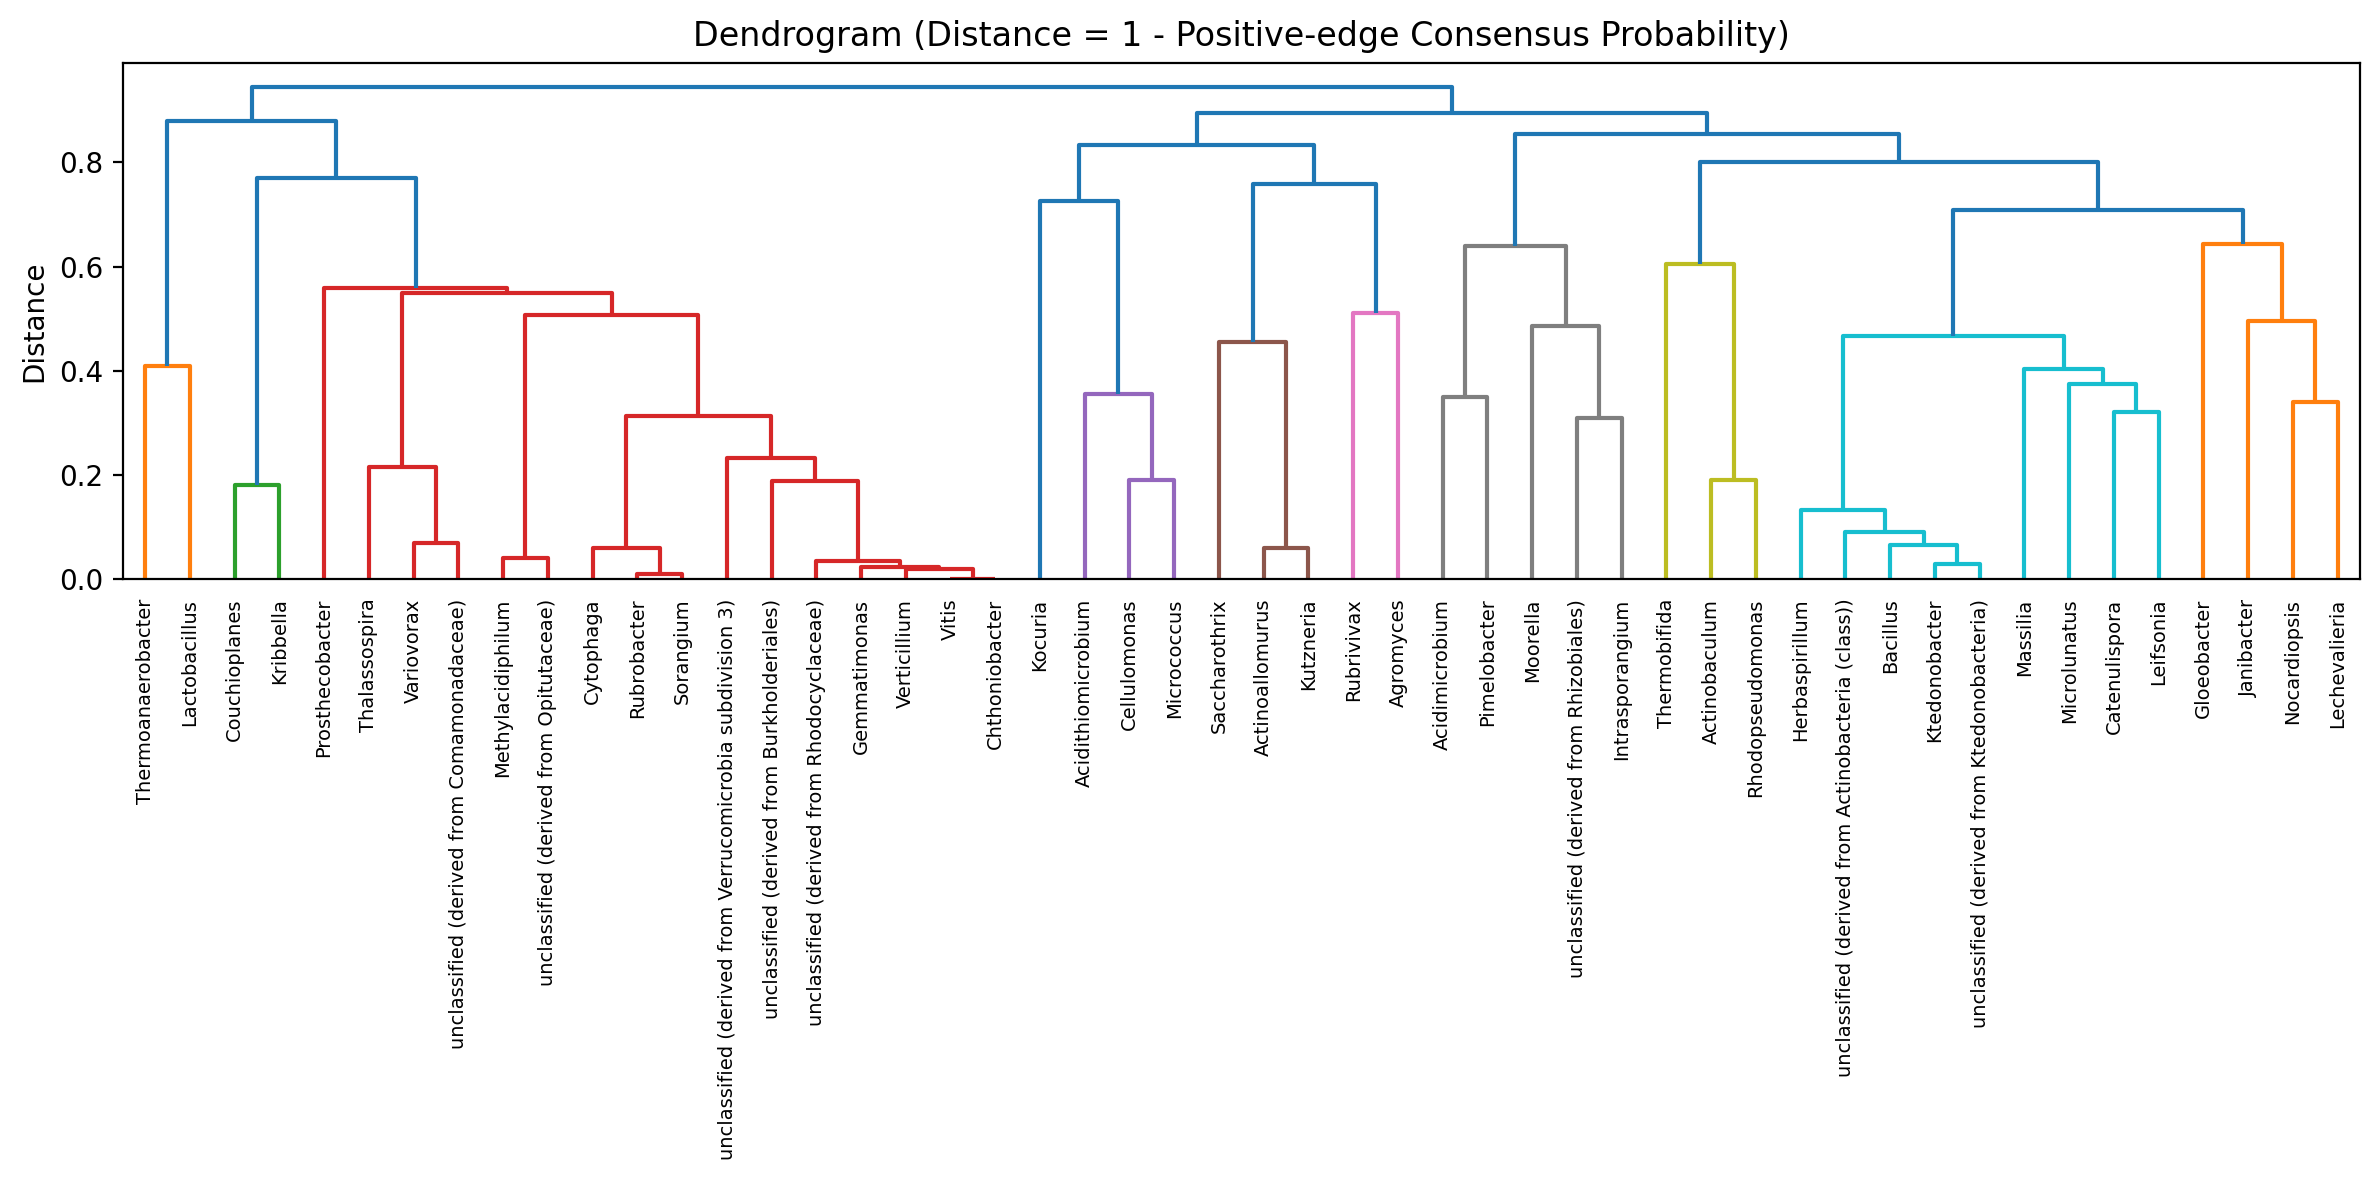

Edges kept: 71 out of 1225 => density 0.05795918367346939


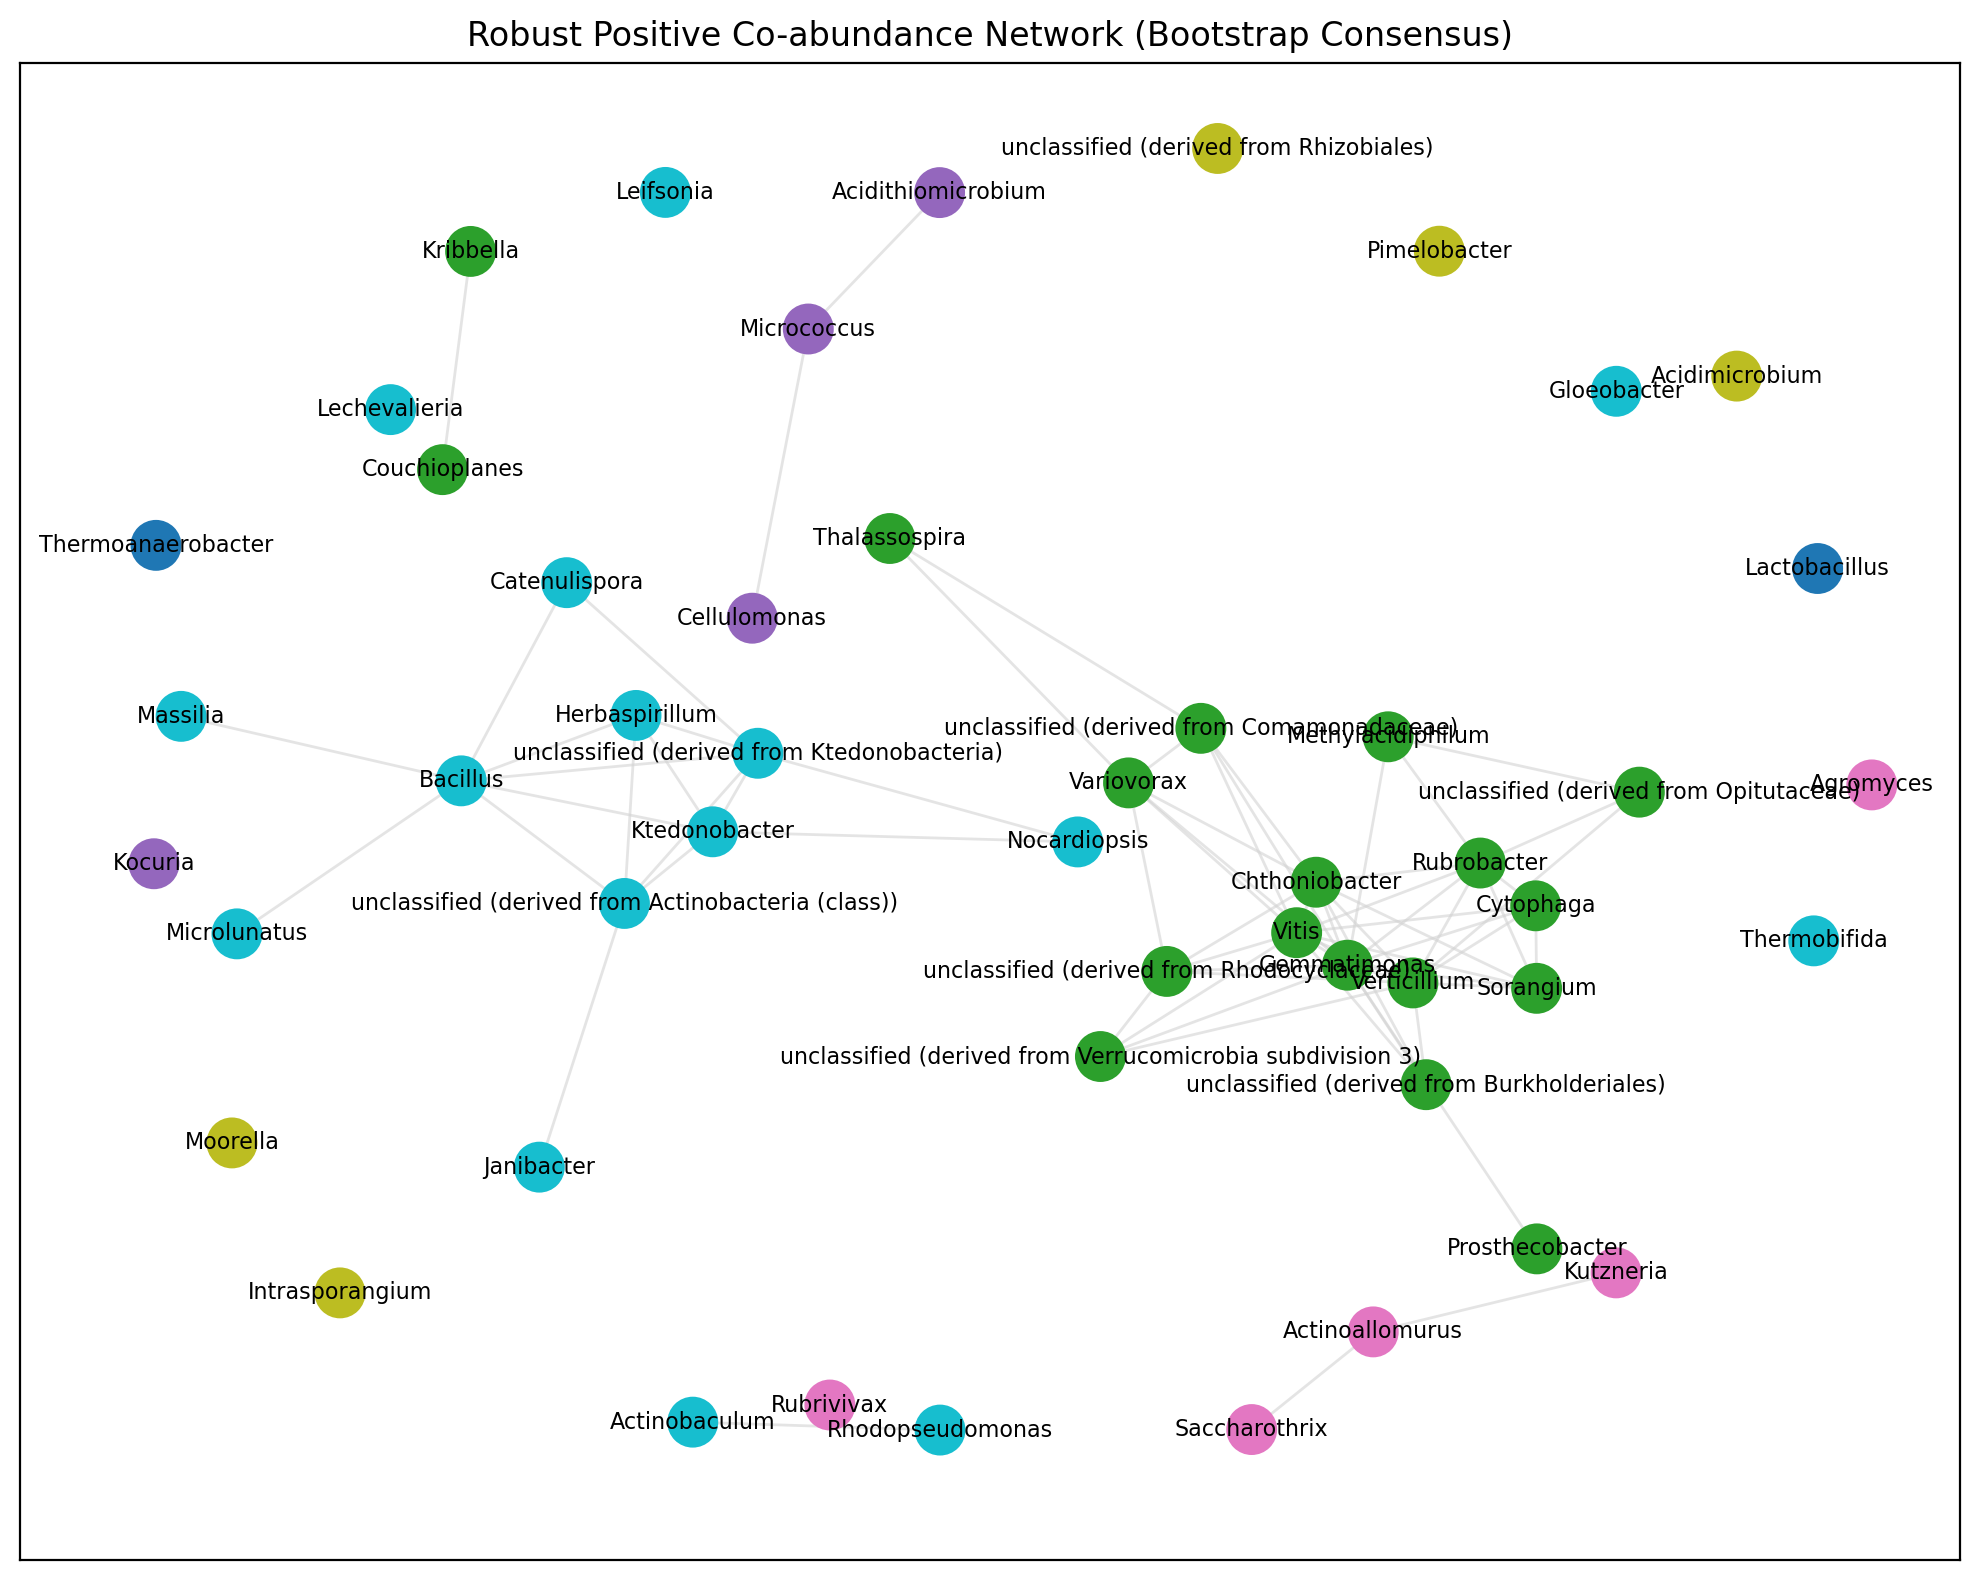

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.utils import resample
import networkx as nx

# ----------------------------
# 1) Load + pick columns
# ----------------------------
path = "/Users/kayadetunji/Downloads/soil study/raw data_taxonomy_CFC.xlsx"
df = pd.read_excel(path)

tax_cols = ['domain', 'phylum', 'className', 'order', 'family', 'genus']
sample_cols = [c for c in df.columns if c not in tax_cols]

taxa = df[tax_cols].fillna("Unclassified")
counts = df[sample_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# ----------------------------
# 2) Prevalence filter (robustness)
# ----------------------------
min_prev = 3
prev_mask = (counts > 0).sum(axis=1) >= min_prev
counts_f = counts.loc[prev_mask].copy()
taxa_f = taxa.loc[prev_mask].copy()

# collapse by genus if you have duplicate genus rows (optional but often important)
# (sum counts across rows that share same genus)
counts_f.index = taxa_f['genus'].values
counts_f = counts_f.groupby(counts_f.index).sum()

print("Taxa after prevalence + genus collapse:", counts_f.shape[0])

# ----------------------------
# 3) CLR transform (compositional aware)
# ----------------------------
def clr_transform(df_counts, pseudocount=1.0):
    X = np.log(df_counts + pseudocount)
    return X.sub(X.mean(axis=0), axis=1)  # center per sample

X_clr = clr_transform(counts_f)

# OPTIONAL: cap to top N taxa by variance (for readability, like your first code)
use_topN = True
topN = 50
if use_topN and X_clr.shape[0] > topN:
    var = X_clr.var(axis=1)
    keep = var.sort_values(ascending=False).head(topN).index
    X_clr = X_clr.loc[keep]
    print("Taxa after top-variance cap:", X_clr.shape[0])

# ----------------------------
# 4) Bootstrap consensus (POSITIVE ONLY)
# ----------------------------
n_boot = 100
r_threshold = 0.5       # "strong positive correlation" definition
consensus_keep = 0.7    # edge must appear in >=70% bootstraps to be kept

taxa_names = X_clr.index.to_list()
n_taxa = len(taxa_names)

# We bootstrap samples (columns) by resampling sample indices with replacement
X = X_clr.T  # samples x taxa
consensus = np.zeros((n_taxa, n_taxa), dtype=float)

for b in range(n_boot):
    X_res = resample(X, replace=True, n_samples=X.shape[0], random_state=42 + b)
    corr, _ = spearmanr(X_res, axis=0)
    corr = np.nan_to_num(corr)

    # POSITIVE ONLY
    adj = (corr >= r_threshold).astype(int)
    consensus += adj

consensus /= n_boot

# remove diagonal for meaningful density calculations
np.fill_diagonal(consensus, 0)

# ----------------------------
# 5) Dendrogram on (1 - consensus)
# ----------------------------
dist = 1 - consensus
dist_array = squareform(dist, checks=False)
Z = linkage(dist_array, method='average')

plt.figure(figsize=(12, 6), dpi=200)
dendrogram(Z, labels=taxa_names, leaf_rotation=90, leaf_font_size=7)
plt.title("Dendrogram (Distance = 1 - Positive-edge Consensus Probability)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# choose number of modules (k) like your first code
k = 6 if n_taxa >= 30 else max(2, int(np.ceil(n_taxa / 5)))
module_labels = fcluster(Z, k, criterion='maxclust')
module_map = {taxa_names[i]: int(module_labels[i]) for i in range(n_taxa)}

# ----------------------------
# 6) Network from consensus edges
# ----------------------------
G = nx.Graph()
for g in taxa_names:
    G.add_node(g, module=module_map[g])

# Add edges where consensus >= 0.7
for i in range(n_taxa):
    for j in range(i + 1, n_taxa):
        p = consensus[i, j]
        if p >= consensus_keep:
            # store consensus probability as weight
            G.add_edge(taxa_names[i], taxa_names[j], weight=float(p))

# Report density (excluding diagonal)
possible_edges = n_taxa * (n_taxa - 1) / 2
print("Edges kept:", G.number_of_edges(), "out of", int(possible_edges),
      "=> density", G.number_of_edges() / possible_edges)

# ----------------------------
# 7) Plot network
# ----------------------------
plt.figure(figsize=(10, 8), dpi=200)
pos = nx.spring_layout(G, seed=42, k=0.5)

node_modules = [d['module'] for _, d in G.nodes(data=True)]
# Draw edges
nx.draw_networkx_edges(
    G, pos,
    edge_color="lightgray",
    alpha=0.6
)

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_modules,
    cmap=plt.cm.tab10,
    node_size=300
)

# Draw labels
nx.draw_networkx_labels(
    G, pos,
    font_size=8
)
plt.title("Robust Positive Co-abundance Network (Bootstrap Consensus)")
plt.tight_layout()
plt.show()

# ----------------------------
# 8) Save module labels
# ----------------------------
# module_df = pd.DataFrame({"taxa": taxa_names, "module": node_modules})
# module_df.to_csv("taxa_modules.csv", index=False)